In [1]:
import pymaid
import navis as nv
import matplotlib.pyplot as plt
import time
from neuroboom import dendrogram as nbd
import neuroboom as nb

instance = pymaid.CatmaidInstance(server='https://radagast.hms.harvard.edu/dorsalhorn/',
                            api_token='REPLACE_WITH_YOUR_CATMAID_API_TOKEN',
                            project_id=13,
                            http_user='', # omit if not required
                            http_password='') # omit if not required
#get ya neuron
neuron = pymaid.get_neuron([216674
,217446
,218411
,219641
,224634
,225173])

INFO  : Global CATMAID instance set. Caching is ON. (pymaid)


Fetch neurons:   0%|          | 0/6 [00:00<?, ?it/s]

Make nrn:   0%|          | 0/6 [00:00<?, ?it/s]

In [2]:
def find_tag(key,neuron):
    if key in neuron.connector_tags.keys():
        return neuron.connector_tags[key]
    else:
        return []

In [3]:
pd=[]
vd=[]
preaxon=[]
predendrite=[]
selfffi=[]
selfpsi=[]
for index,n in enumerate(neuron):
    pd+=find_tag('pd',n)
    vd+=find_tag('vd',n)
    preaxon+=find_tag('pre-vaxon',n)
    predendrite+=find_tag('pre-vdendrite',n)
    selfffi+=find_tag('self-ffi',n)
    selfpsi+=find_tag('self-psi',n)
len(preaxon),len(pd+vd)

(108, 429)

In [4]:
len(selfffi)/len(pd),len(pd)

(0.15, 320)

Pruning:   0%|          | 0/6 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/6 [00:00<?, ?it/s]

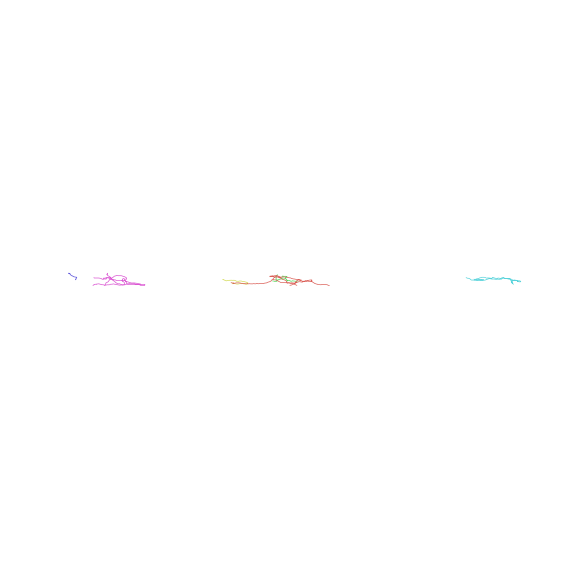

In [5]:
#visulaize the morphology of pruned neuron
n_pr_size = nv.prune_twigs(neuron,
                         size='2 microns',
                         recursive=float('inf'),
                         inplace=False)
fig, ax = n_pr_size.plot2d()  # equivalent to `navis.plot2d(nl)`
plt.show()

In [6]:
#define functions to return the parent node id of node that survide after pruning
def parent_id(x):
    parent=neuron.nodes[neuron.nodes['node_id']==x]['parent_id'].values[0]
    return parent

def parent_after_prune(x):
    while sum(n_pr_size.nodes['node_id'].isin([x]))==0:
        x=parent_id(x)
        
    return x


In [7]:
#relocate the connectors
for j in neuron:
    cn = j.connectors
    id_prune=[]
    for i in cn['node_id']:
        id_prune.append(parent_after_prune(i))
    
    cn['node_id']=id_prune

In [8]:
#pruned the neuron
pruned= nv.prune_twigs(neuron,
                         size='2 microns',
                         recursive=float('inf'),
                         inplace=False)

Pruning:   0%|          | 0/6 [00:00<?, ?it/s]

In [9]:
pruned

,type,name,skeleton_id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units
0,CatmaidNeuron,neuron 216675,216674,753,68,3,4,405960.187500,None,1 nanometer
1,CatmaidNeuron,neuron 217447,217446,185,101,0,1,83505.046875,None,1 nanometer
...,...,...,...,...,...,...,...,...,...,...
4,CatmaidNeuron,neuron 224635,224634,117,72,0,2,37103.246094,None,1 nanometer
5,CatmaidNeuron,neuron 225174,225173,815,51,3,5,406822.343750,None,1 nanometer


In [10]:
#calculate the distance, unit is nm
m=[]
for i,j in enumerate(pruned):
    m.append(nv.geodesic_matrix(j,weight='weight'))

In [11]:
def find_tag(key,neuron):
    if key in neuron.connector_tags.keys():
        return neuron.connector_tags[key]
    else:
        return []
    

In [12]:
def connector_tuple(key,neuron):
    connector_node=[]
    if key in neuron.connector_tags.keys():
        for i in neuron.connector_tags[key]:
            connector_node+=[neuron.connectors[neuron.connectors['connector_id']==i]['node_id'] ]
        connections = dict(zip(neuron.connector_tags[key], connector_node))
        return connections
    else:
        return []

In [13]:
synapse_node=[]
import numpy as np
for index,neuron in enumerate(pruned):
    synapse_connector=find_tag('pre-vaxon',neuron)+find_tag('pd',neuron)+find_tag('vd',neuron)
    neuron_node=[]
    for i,node in enumerate(synapse_connector):
        neuron_node=np.append(neuron_node,neuron.connectors[neuron.connectors['connector_id']==node]['node_id'])
    synapse_node.append(np.unique(neuron_node))
 
#    pd_node=np.zeros(len(pd_connector))
#    for i,node in enumerate(pd_connector):
#        pd_node[i]=neuron.connectors[neuron.connectors['connector_id']==node]['node_id']
#    pd_to_psi=m[index].loc[psi_node, pd_node]
#    psi_close+=(list((pd_to_psi < 4000).sum()))


In [14]:
node_matrix=[]
for i,node in enumerate(synapse_node):
    node_matrix.append(m[i].loc[node,node])

In [15]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

def get_connected_nodes_df(distance_df, start_node, threshold=1.0):
    """
    Given a pandas DataFrame representing a distance matrix, find the connected component
    starting from `start_node` where nodes are connected if the distance is below `threshold`.
    
    Parameters:
      distance_df: A pandas DataFrame with nodes as both the index and columns.
      start_node: The node (index) from which to start the search.
      threshold: The maximum distance to consider nodes as connected (default is 1.0 µm).
      
    Returns:
      A set of node labels that are connected (directly or indirectly) with the start_node.
    """
    visited = set()
    to_visit = [start_node]
    
    while to_visit:
        current = to_visit.pop()
        if current in visited:
            continue
        visited.add(current)
        # Find neighbors: nodes with a distance less than the threshold.
        neighbors = distance_df.loc[current][distance_df.loc[current] < threshold].index.tolist()
        for neighbor in neighbors:
            if neighbor not in visited:
                to_visit.append(neighbor)
    return visited

def cluster_all_nodes(distance_df, threshold=1.0):
    """
    Clusters all nodes in a single DataFrame into connected components based on the distance threshold.
    
    Parameters:
      distance_df: A pandas DataFrame representing the distance matrix.
      threshold: The maximum distance to consider nodes as connected.
    
    Returns:
      A list of clusters, where each cluster is a list of connected node labels.
    """
    unvisited_nodes = set(distance_df.index)
    clusters = []
    
    while unvisited_nodes:
        start_node = unvisited_nodes.pop()
        connected_set = get_connected_nodes_df(distance_df, start_node, threshold=threshold)
        unvisited_nodes -= connected_set
        clusters.append(list(connected_set))
    return clusters

def cluster_all_matrices(distance_dfs, threshold=1.0):
    """
    Clusters nodes from a list of pandas DataFrames (each representing a distance matrix).
    For each matrix, nodes are clustered based on the threshold, and then all clusters
    from different matrices are combined.
    
    Parameters:
      distance_dfs: A list of pandas DataFrames where each DataFrame is a distance matrix.
      threshold: The maximum distance to consider nodes as connected.
    
    Returns:
      A list of clusters (each cluster is a list of node labels) from all matrices.
    """
    all_clusters = []
    for idx, distance_df in enumerate(distance_dfs):
        clusters = cluster_all_nodes(distance_df, threshold=threshold)
        # Optionally, tag clusters with the matrix index if needed:
        # clusters = [[(idx, node) for node in cluster] for cluster in clusters]
        all_clusters.extend(clusters)
    return all_clusters



In [16]:
all_clusters=cluster_all_matrices(node_matrix, threshold=2000)


In [17]:
def get_cluster_connector_ids(clusters, dataframes):
    """
    For each cluster (a list of node IDs), search across a list of DataFrames
    to find the 'connector_id' values where 'node_id' matches any node in the cluster.
    
    Parameters:
      clusters: A list of clusters (each cluster is a list of node IDs).
      dataframes: A list of pandas DataFrames that have 'node_id' and 'connector_id' columns.
      
    Returns:
      A list of clusters, where each cluster is a list of 'connector_id' values.
    """
    clusters_connector_ids = []
    
    for cluster in clusters:
        cluster_ids = []
        for node in cluster:
            for df in dataframes:
                # Find matching rows in the current DataFrame where 'node_id' equals the current node.
                matching_connector_ids = df.loc[df['node_id'] == node, 'connector_id'].tolist()
                cluster_ids.extend(matching_connector_ids)
        clusters_connector_ids.append(cluster_ids)
        
    return clusters_connector_ids

# Get the connector_id values for each cluster.
connector_df=[]
for i in pruned:
    connector_df.append(i.connectors)

connector_clusters = get_cluster_connector_ids(all_clusters, connector_df)
connector_clusters

[[682624,
  682527,
  682538,
  682522,
  682529,
  682534,
  682536,
  682545,
  682548,
  682549,
  682551,
  682553,
  682555,
  682557,
  682612,
  682569,
  682571,
  682583,
  682606,
  682588,
  682595,
  682597,
  682599,
  682602,
  682603,
  682613,
  682580,
  682540,
  682544,
  682618,
  682621,
  682623,
  682560,
  682581,
  682562,
  682566,
  682567,
  682609,
  682573,
  682594,
  682576,
  682586,
  682590,
  682615],
 [682627],
 [682640,
  682643,
  682646,
  682630,
  682633,
  682635,
  682644,
  682650,
  682652,
  682638,
  682648],
 [682508, 682511, 682512, 682514, 682516, 682518, 682520],
 [682657, 682666, 682661, 682663, 682654],
 [683379,
  683361,
  683339,
  683341,
  683335,
  683337,
  683320,
  683315,
  683326,
  683328,
  683295,
  683285,
  683291,
  683287,
  683293,
  683297,
  683300,
  683324,
  683305,
  683307,
  683312,
  683309,
  683317,
  683321,
  683331,
  683334,
  683343,
  683346,
  683350,
  683357,
  683359,
  683352,
  683355,
  683

In [18]:
def get_combined_key_clusters_with_duplicates(connector_clusters, dict_list):
    """
    For each connector cluster (a list of node IDs), search each dictionary in dict_list 
    for keys whose value lists contain any node from the cluster.
    Each match is counted individually, so if a key's value list contains multiple nodes 
    from the cluster, it will be added multiple times.
    
    Parameters:
      connector_clusters: List[List[int]]
        A list of connector clusters (each a list of node IDs).
      dict_list: List[dict]
        A list of dictionaries with the same keys and mutually exclusive value lists.
        
    Returns:
      List[List[str]]: A list where each element is a list of keys (with duplicates)
      that matched for the corresponding connector cluster.
    """
    result = []
    for cluster in connector_clusters:
        cluster_keys = []
        # Iterate over each dictionary
        for d in dict_list:
            # For each key and its associated list of values in the dictionary,
            # check for each node in the cluster whether it is present.
            for key, values in d.items():
                for node in cluster:
                    if node in values:
                        cluster_keys.append(key)
        result.append(cluster_keys)
    return result

connector_dict=[]
for i in pruned:
    connector_dict.append(i.connector_tags)

result=get_combined_key_clusters_with_duplicates(connector_clusters, connector_dict)

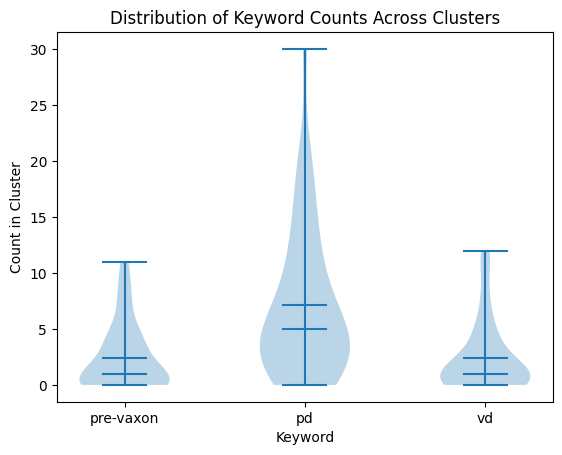

In [19]:
import matplotlib.pyplot as plt
# Define the keywords we want to quantify.
keywords = ['pre-vaxon', 'pd', 'vd']

# For each keyword, gather the count of its appearances in each cluster.
# This creates a list of lists where each inner list corresponds to a keyword's counts across clusters.
keyword_counts = []
for kw in keywords:
    counts = [cluster.count(kw) for cluster in result]
    keyword_counts.append(counts)

# Now create a violin plot using matplotlib.
fig, ax = plt.subplots()

# Create the violin plot.
# The data should be a list of arrays (or lists) with each inner list corresponding to one category.
parts = ax.violinplot(keyword_counts, showmeans=True, showmedians=True)

# Set the x-tick positions and labels.
ax.set_xticks(np.arange(1, len(keywords) + 1))
ax.set_xticklabels(keywords)

ax.set_xlabel("Keyword")
ax.set_ylabel("Count in Cluster")
ax.set_title("Distribution of Keyword Counts Across Clusters")

plt.show()

In [20]:
len(keyword_counts[0])

45

In [22]:
import json

# Save the keyword_counts list to a JSON file.
with open("keyword_counts_mrgd.json", "w") as f:
    json.dump(keyword_counts, f)